# Travel Reimbursement Approval Agent

**Ashish Mishra**

A working prototype that reviews the five sample travel claims against the mock policy in the assignment. The agent calls tools for policy text, receipts, limits, the approval tier, timeliness, and duplicates, then returns one structured decision per claim.

## README

### Setup

1. Use Python 3.11 or newer.
2. In the folder that contains this notebook, create a file named `.env`:

```
GEMINI_API_KEY=your_key_here
```

`GOOGLE_API_KEY` is accepted as a fallback. Optional: `GEMINI_MODEL` (default `gemini-3.5-flash-lite`).

3. Open this notebook and run every cell from top to bottom. The first code cell installs `google-genai`, `matplotlib`, and `python-dotenv`.

Keep the key in `.env`. Do not commit it.

### How the demo runs

- Claim intake is the Appendix B JSON in this notebook (`load_claims`).
- Gemini has to call the policy and checking tools before it decides. Each call is printed.
- The last code cell prints a JSON array with one object per claim.
- The dashboard is rendered under Dashboard and saved as `UI SS_1.png` next to this notebook.

### Design choices

- The model chooses the tools and writes the explanation. Caps, receipt rules, and approval tiers come back from tools.
- Temperature is 0. If a draft disagrees with the tool results, the notebook asks the model to revise it. The notebook does not overwrite the decision.
- `tools_used` is the list of calls that actually ran.
- Incomplete, exception, and high-value cases go to Manual Review. Those claims are not auto-paid and not auto-deducted.


In [1]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "google-genai", "matplotlib", "python-dotenv",
])


0

In [2]:
import json
import os
import re
import time
from datetime import date
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai
from google.genai import types
from IPython.display import Image, display

load_dotenv(Path.cwd() / ".env")
API_KEY = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "Set GEMINI_API_KEY or GOOGLE_API_KEY in a .env file next to this notebook, then run all cells again."
    )

MODEL_CANDIDATES = []
if os.getenv("GEMINI_MODEL"):
    MODEL_CANDIDATES.append(os.getenv("GEMINI_MODEL"))
MODEL_CANDIDATES.extend([
    "gemini-3.5-flash-lite",
    "gemini-3.8-flash",
    "gemini-2.5-flash",
])
MODEL_CANDIDATES = list(dict.fromkeys(MODEL_CANDIDATES))
client = genai.Client(api_key=API_KEY)
print("Gemini client ready. Model preference:", ", ".join(MODEL_CANDIDATES))


Gemini client ready. Model preference: gemini-3.5-flash-lite, gemini-3.8-flash, gemini-2.5-flash


## Policy and claims

Appendix A is stored with the stable `POL-*` ids. Appendix B is loaded from JSON. The totals are the totals stated in the assignment.


In [3]:
POLICY = {
    "POL-CAT-01": "Eligible categories. Reimbursable when incurred for a documented business purpose: airfare (economy class only, see POL-AIR-01); lodging (hotel room charges); meals (subject to per-diem limits, see POL-PD-01); ground transport (taxi, rideshare, train, rental car, parking); conference / registration fees.",
    "POL-CAT-02": "Ineligible items. Never reimbursable; rejected (deducted in full): alcohol and minibar charges; spa, gym, and personal entertainment; in-room movies, personal shopping, gifts; traffic fines, penalties, and late fees; any personal (non-business) expense.",
    "POL-PD-01": "Meals. Maximum USD 75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.",
    "POL-PD-02": "Lodging. Maximum USD 200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.",
    "POL-PD-03": "Ground transport. Maximum USD 50 per day. Amounts above the cap are deducted.",
    "POL-AIR-01": "Airfare class. Only economy class airfare is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review (not auto-deducted, because a pre-approval may exist).",
    "POL-RCT-01": "Receipt required above USD 25. Any single line item greater than USD 25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount.",
    "POL-RCT-02": "Missing receipt handling. If a receipt is missing for an item that requires one, the item is not silently rejected. The claim is routed to Manual Review so the reviewer can request the receipt.",
    "POL-APR-01": "Auto-approve tier. Total reimbursable amount <= USD 500: may be auto-approved by the agent if fully compliant.",
    "POL-APR-02": "Manager tier. Total reimbursable amount > USD 500 and <= USD 2,000: eligible for approval, treated as approvable when fully compliant.",
    "POL-APR-03": "Director / Manual-Review tier. Total reimbursable amount > USD 2,000: exceeds the agent's auto-approval authority and must be routed to Manual Review (director approval required), even if otherwise compliant.",
    "POL-TIME-01": "Submission window. Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review.",
}

POLICY_ORDER = list(POLICY)
ELIGIBLE_CATEGORIES = {"airfare", "lodging", "meals", "ground_transport", "conference_fees"}
INELIGIBLE_CATEGORIES = {
    "spa", "gym", "minibar", "alcohol", "entertainment", "movies",
    "shopping", "gifts", "fine", "penalty", "late_fee", "personal",
}
CAP_RULES = {
    "meals": ("day", 75.0, "POL-PD-01"),
    "lodging": ("night", 200.0, "POL-PD-02"),
    "ground_transport": ("day", 50.0, "POL-PD-03"),
}
DECISIONS = ("APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW")
OUTPUT_FIELDS = (
    "claim_id", "decision", "approved_amount", "deducted_amount",
    "missing_docs", "policy_refs", "confidence", "explanation", "tools_used",
)

CLAIMS_JSON = r"""
[
  {
    "claim_id": "CLM-001",
    "purpose": "Attend 2-day industry conference (business)",
    "employee": "A. Rivera",
    "trip_start": "2026-06-10",
    "trip_end": "2026-06-12",
    "submitted": "2026-06-20",
    "currency": "USD",
    "line_items": [
      {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": true},
      {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": true},
      {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": true},
      {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-002",
    "purpose": "Weekend hotel stay",
    "employee": "B. Osei",
    "trip_start": "2026-06-14",
    "trip_end": "2026-06-15",
    "submitted": "2026-06-25",
    "currency": "USD",
    "line_items": [
      {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": true},
      {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-003",
    "purpose": "Client site visit (business)",
    "employee": "C. Nakamura",
    "trip_start": "2026-06-08",
    "trip_end": "2026-06-10",
    "submitted": "2026-06-22",
    "currency": "USD",
    "line_items": [
      {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": true},
      {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": true},
      {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-004",
    "purpose": "International vendor negotiation (business)",
    "employee": "D. Fischer",
    "trip_start": "2026-06-16",
    "trip_end": "2026-06-18",
    "submitted": "2026-06-28",
    "currency": "USD",
    "line_items": [
      {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": true},
      {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": false}
    ]
  },
  {
    "claim_id": "CLM-005",
    "purpose": "Client dinner / business development",
    "employee": "E. Haddad",
    "trip_start": "2026-06-11",
    "trip_end": "2026-06-11",
    "submitted": "2026-06-24",
    "currency": "USD",
    "line_items": [
      {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": false}
    ]
  }
]
"""


def money(value):
    return round(float(value) + 1e-9, 2)


def load_claims(source):
    # JSON string, path to a JSON file, or an already parsed object.
    if isinstance(source, list):
        data = source
    elif isinstance(source, dict):
        data = [source]
    else:
        text = source
        path = Path(str(source))
        if path.suffix.lower() == ".json" and path.exists():
            text = path.read_text(encoding="utf-8")
        data = json.loads(text)
        if isinstance(data, dict):
            data = [data]
    if not isinstance(data, list) or not data:
        raise ValueError("Claim intake must be a non-empty JSON array of claims.")
    return data


def ordered_refs(refs):
    found = set(refs)
    return [rule_id for rule_id in POLICY_ORDER if rule_id in found]


def _count_in_text(description, unit):
    match = re.search(rf"(\d+)\s*{unit}s?", description, re.IGNORECASE)
    return int(match.group(1)) if match else None


def _airfare_class(description):
    text = description.lower()
    if "first" in text and "class" in text:
        return "first"
    if "business" in text:
        return "business"
    if "economy" in text:
        return "economy"
    return None


def _line(line, **overrides):
    base = {
        "description": line["description"],
        "category": str(line["category"]).strip().lower(),
        "amount": money(line["amount"]),
        "eligible": False,
        "receipt_required": False,
        "receipt_attached": bool(line["receipt_attached"]),
        "missing_receipt": False,
        "reimbursable_if_settled": 0.0,
        "deducted_if_settled": 0.0,
        "include_in_threshold": 0.0,
        "status": "ambiguous",
        "policy_refs": [],
        "note": "",
    }
    base.update(overrides)
    return base


def analyze_line(claim, line):
    category = str(line["category"]).strip().lower()
    amount = money(line["amount"])
    description = line["description"]
    attached = bool(line["receipt_attached"])
    receipt_required = amount > 25 or category in {"airfare", "lodging"}
    refs = ["POL-RCT-01"] if receipt_required else []
    missing = receipt_required and not attached

    if category in INELIGIBLE_CATEGORIES:
        refs.append("POL-CAT-02")
        if missing:
            refs.append("POL-RCT-02")
        note = "Ineligible under POL-CAT-02 and deducted in full when the claim is settled."
        if missing:
            note += " A required receipt is also missing, so the claim cannot be silently rejected."
        return _line(
            line,
            eligible=False,
            receipt_required=receipt_required,
            missing_receipt=missing,
            reimbursable_if_settled=0.0,
            deducted_if_settled=0.0 if missing else amount,
            include_in_threshold=0.0,
            status="missing_receipt" if missing else "ineligible",
            policy_refs=ordered_refs(refs),
            note=note,
        )

    if category not in ELIGIBLE_CATEGORIES:
        return _line(
            line,
            receipt_required=receipt_required,
            missing_receipt=missing,
            include_in_threshold=amount,
            status="ambiguous",
            policy_refs=ordered_refs(refs),
            note="Category is not listed as eligible or ineligible. Route the claim to Manual Review.",
        )

    refs.append("POL-CAT-01")
    notes = []
    cap_amount = amount

    if category == "airfare":
        fare_class = _airfare_class(description)
        if fare_class in {"business", "first"}:
            refs.append("POL-AIR-01")
            if missing:
                refs.append("POL-RCT-02")
            return _line(
                line,
                eligible=True,
                receipt_required=True,
                missing_receipt=missing,
                include_in_threshold=amount,
                status="class_exception",
                policy_refs=ordered_refs(refs),
                note=fare_class.title() + "-class airfare is a POL-AIR-01 exception and is not auto-deducted.",
            )
        if fare_class != "economy":
            refs.append("POL-AIR-01")
            return _line(
                line,
                eligible=True,
                receipt_required=True,
                missing_receipt=missing,
                include_in_threshold=amount,
                status="ambiguous",
                policy_refs=ordered_refs(refs),
                note="Airfare class is not stated, so POL-AIR-01 cannot be applied automatically.",
            )
        refs.append("POL-AIR-01")
        notes.append("Economy class is reimbursable under POL-AIR-01.")

    if category in CAP_RULES:
        unit, cap, rule_id = CAP_RULES[category]
        refs.append(rule_id)
        count = _count_in_text(description, unit)
        if count is None and category == "meals" and claim["trip_start"] == claim["trip_end"]:
            count = 1
            notes.append("Same-day trip, so the meal line is treated as one day.")
        if count is None:
            return _line(
                line,
                eligible=True,
                receipt_required=receipt_required,
                missing_receipt=missing,
                include_in_threshold=amount,
                status="ambiguous",
                policy_refs=ordered_refs(refs),
                note="The description does not state how many " + unit + "s this line covers, so the cap cannot be applied.",
            )
        cap_amount = money(cap * count)
        notes.append(rule_id + " cap is USD " + format(cap, ".0f") + " per " + unit + " x " + str(count) + " = USD " + format(cap_amount, ".2f") + ".")
    else:
        notes.append("No numeric cap in the policy for this category.")

    if missing:
        refs.append("POL-RCT-02")
        extra = ""
        if amount > cap_amount:
            extra = " The line is also USD " + format(money(amount - cap_amount), ".2f") + " over the cap. Do not partial-approve while the receipt is missing."
        return _line(
            line,
            eligible=True,
            receipt_required=receipt_required,
            missing_receipt=True,
            include_in_threshold=money(min(amount, cap_amount)),
            status="missing_receipt",
            policy_refs=ordered_refs(refs),
            note="Required receipt is missing (POL-RCT-02). Do not silently reject this line." + extra,
        )

    reimbursable = money(min(amount, cap_amount))
    deducted = money(amount - reimbursable)
    if deducted > 0:
        notes.append("USD " + format(deducted, ".2f") + " is above the cap and is deducted when the claim is settled.")
        status = "over_cap"
    else:
        status = "ok"
    return _line(
        line,
        eligible=True,
        receipt_required=receipt_required,
        missing_receipt=False,
        reimbursable_if_settled=reimbursable,
        deducted_if_settled=deducted,
        include_in_threshold=reimbursable,
        status=status,
        policy_refs=ordered_refs(refs),
        note=" ".join(notes),
    )


def find_claim(claim_id):
    for claim in CLAIMS:
        if claim["claim_id"] == claim_id:
            return claim
    known = ", ".join(claim["claim_id"] for claim in CLAIMS)
    raise KeyError("Unknown claim_id " + repr(claim_id) + ". Known claims: " + known)


def analyze(claim):
    lines = [analyze_line(claim, line) for line in claim["line_items"]]
    claimed_total = money(sum(item["amount"] for item in claim["line_items"]))
    expense_date = date.fromisoformat(claim["trip_end"])
    submitted_on = date.fromisoformat(claim["submitted"])
    days_after = (submitted_on - expense_date).days
    late = days_after > 30

    duplicates = []
    for other in CLAIMS:
        if other["claim_id"] == claim["claim_id"]:
            continue
        same_employee = other["employee"].strip().lower() == claim["employee"].strip().lower()
        overlaps = not (other["trip_end"] < claim["trip_start"] or other["trip_start"] > claim["trip_end"])
        if same_employee and overlaps:
            duplicates.append(other["claim_id"])

    reasons = []
    missing_docs = []
    refs = set()
    reimbursable = 0.0
    threshold_amount = 0.0
    for line in lines:
        refs.update(line["policy_refs"])
        threshold_amount = money(threshold_amount + line["include_in_threshold"])
        if line["status"] in {"ok", "over_cap", "ineligible"}:
            reimbursable = money(reimbursable + line["reimbursable_if_settled"])
        if line["missing_receipt"]:
            missing_docs.append(line["description"])
            reasons.append(line["description"] + ": required receipt is missing (POL-RCT-02).")
        if line["status"] == "class_exception":
            reasons.append(line["description"] + ": " + line["note"])
        if line["status"] == "ambiguous":
            reasons.append(line["description"] + ": " + line["note"])

    refs.add("POL-TIME-01")
    if late:
        reasons.append(
            "Submitted " + str(days_after) + " days after the trip end date " + claim["trip_end"] + " (POL-TIME-01)."
        )
    if duplicates:
        reasons.append("Possible duplicate for the same employee and overlapping dates: " + ", ".join(duplicates) + ".")

    if threshold_amount > 2000:
        tier = "POL-APR-03"
        reasons.append(
            "Amount used for the approval threshold is USD " + format(threshold_amount, ".2f") + ", which is above USD 2,000 (POL-APR-03)."
        )
    elif threshold_amount > 500:
        tier = "POL-APR-02"
    else:
        tier = "POL-APR-01"
    refs.add(tier)

    if reasons:
        decision = "MANUAL_REVIEW"
        approved = 0.0
        deducted = 0.0
    elif reimbursable == 0:
        decision = "REJECT"
        approved = 0.0
        deducted = claimed_total
        refs.add("POL-CAT-02")
    elif reimbursable < claimed_total:
        decision = "PARTIAL_APPROVE"
        approved = reimbursable
        deducted = money(claimed_total - reimbursable)
    else:
        decision = "APPROVE"
        approved = claimed_total
        deducted = 0.0

    return {
        "claim_id": claim["claim_id"],
        "claimed_total": claimed_total,
        "lines": lines,
        "missing_docs": missing_docs,
        "manual_review_reasons": reasons,
        "threshold_amount": threshold_amount,
        "approval_tier": tier,
        "forces_manual_review_tier": tier == "POL-APR-03",
        "expense_date": claim["trip_end"],
        "submitted": claim["submitted"],
        "days_after_expense": days_after,
        "late": late,
        "duplicates": duplicates,
        "decision": decision,
        "approved_amount": approved,
        "deducted_amount": deducted,
        "policy_refs": ordered_refs(refs),
        "expense_date_basis": "Trip end date. Line items in Appendix B do not have their own dates.",
    }


CLAIMS = load_claims(CLAIMS_JSON)
STATED_TOTALS = {
    "CLM-001": 1110.00,
    "CLM-002": 380.00,
    "CLM-003": 940.00,
    "CLM-004": 3000.00,
    "CLM-005": 220.00,
}
for claim in CLAIMS:
    total = money(sum(line["amount"] for line in claim["line_items"]))
    if total != STATED_TOTALS[claim["claim_id"]]:
        raise AssertionError(claim["claim_id"] + " lines sum to " + str(total))

print("Loaded " + str(len(CLAIMS)) + " claims from Appendix B JSON.")
for claim in CLAIMS:
    print("  " + claim["claim_id"] + ": " + claim["employee"] + " | " + claim["purpose"] + " | USD " + format(STATED_TOTALS[claim["claim_id"]], ".2f"))


Loaded 5 claims from Appendix B JSON.
  CLM-001: A. Rivera | Attend 2-day industry conference (business) | USD 1110.00
  CLM-002: B. Osei | Weekend hotel stay | USD 380.00
  CLM-003: C. Nakamura | Client site visit (business) | USD 940.00
  CLM-004: D. Fischer | International vendor negotiation (business) | USD 3000.00
  CLM-005: E. Haddad | Client dinner / business development | USD 220.00


## Tools

Each tool reads the claim store or the policy table. Gemini chooses which tools to call. The checkers return facts. They do not write the final JSON.


In [4]:
def policy_lookup(rule_id=None, rule_ids=None):
    # Return the text of one or more POL-* rules.
    requested = []
    if rule_id:
        requested.append(str(rule_id).strip())
    if rule_ids:
        requested.extend(str(item).strip() for item in rule_ids)
    if not requested:
        return {"error": "Pass rule_id or rule_ids.", "available_ids": POLICY_ORDER}
    found = []
    unknown = []
    for item in requested:
        if item in POLICY:
            found.append({"id": item, "text": POLICY[item]})
        else:
            unknown.append(item)
    return {"rules": found, "unknown_ids": unknown}


def check_receipt_completeness(claim_id):
    # Apply POL-RCT-01 and POL-RCT-02 to every line.
    facts = analyze(find_claim(claim_id))
    return {
        "claim_id": claim_id,
        "lines": [
            {
                "description": line["description"],
                "amount": line["amount"],
                "receipt_required": line["receipt_required"],
                "receipt_attached": line["receipt_attached"],
                "missing_receipt": line["missing_receipt"],
                "note": line["note"],
            }
            for line in facts["lines"]
        ],
        "missing_docs": facts["missing_docs"],
        "policy_refs": [rule for rule in facts["policy_refs"] if rule.startswith("POL-RCT")],
    }


def check_category_and_limits(claim_id):
    # Apply categories, per-diem caps, and airfare class.
    facts = analyze(find_claim(claim_id))
    return {
        "claim_id": claim_id,
        "claimed_total": facts["claimed_total"],
        "lines": [
            {
                "description": line["description"],
                "category": line["category"],
                "amount": line["amount"],
                "status": line["status"],
                "reimbursable_if_settled": line["reimbursable_if_settled"],
                "deducted_if_settled": line["deducted_if_settled"],
                "include_in_threshold": line["include_in_threshold"],
                "policy_refs": line["policy_refs"],
                "note": line["note"],
            }
            for line in facts["lines"]
        ],
    }


def check_approval_threshold(claim_id):
    # Apply POL-APR-01, POL-APR-02, and POL-APR-03 after per-diem caps.
    facts = analyze(find_claim(claim_id))
    return {
        "claim_id": claim_id,
        "threshold_basis": (
            "Total reimbursable amount after per-diem caps. "
            "Business/first-class airfare is included because POL-AIR-01 says not to auto-deduct it. "
            "A missing-receipt line contributes its capped amount because POL-RCT-02 says not to silently reject it."
        ),
        "threshold_amount": facts["threshold_amount"],
        "approval_tier": facts["approval_tier"],
        "tier_text": POLICY[facts["approval_tier"]],
        "forces_manual_review": facts["forces_manual_review_tier"],
    }


def check_timeliness(claim_id):
    # Apply the 30-day window in POL-TIME-01.
    facts = analyze(find_claim(claim_id))
    return {
        "claim_id": claim_id,
        "expense_date": facts["expense_date"],
        "expense_date_basis": facts["expense_date_basis"],
        "submitted": facts["submitted"],
        "days_after_expense": facts["days_after_expense"],
        "within_30_days": not facts["late"],
        "late": facts["late"],
        "policy_ref": "POL-TIME-01",
    }


def check_duplicates(claim_id):
    # Same employee and overlapping trip dates, inside the five sample claims only.
    facts = analyze(find_claim(claim_id))
    return {
        "claim_id": claim_id,
        "duplicate_rule": "Same employee and overlapping trip dates, compared only with the five Appendix B claims.",
        "duplicates": facts["duplicates"],
        "conflict": bool(facts["duplicates"]),
    }


def validate_decision(draft_json):
    # Check a draft against the tool facts and return errors for the model to fix.
    if isinstance(draft_json, dict):
        draft = draft_json
    else:
        try:
            draft = json.loads(draft_json)
        except json.JSONDecodeError as exc:
            return {"valid": False, "errors": ["draft_json is not valid JSON: " + str(exc)]}
    claim_id = draft.get("claim_id")
    try:
        facts = analyze(find_claim(claim_id))
    except Exception as exc:
        return {"valid": False, "errors": [str(exc)]}
    errors = _decision_errors(draft, facts, looked_up_ids=None, tools_used=None)
    return {
        "valid": not errors,
        "errors": errors,
        "required_decision": facts["decision"],
        "required_approved_amount": facts["approved_amount"],
        "required_deducted_amount": facts["deducted_amount"],
        "required_missing_docs": facts["missing_docs"],
        "required_policy_refs": facts["policy_refs"],
        "manual_review_reasons": facts["manual_review_reasons"],
    }


TOOL_FUNCTIONS = {
    "policy_lookup": policy_lookup,
    "check_receipt_completeness": check_receipt_completeness,
    "check_category_and_limits": check_category_and_limits,
    "check_approval_threshold": check_approval_threshold,
    "check_timeliness": check_timeliness,
    "check_duplicates": check_duplicates,
    "validate_decision": validate_decision,
}
REQUIRED_TOOLS = [
    "policy_lookup",
    "check_receipt_completeness",
    "check_category_and_limits",
    "check_approval_threshold",
    "check_timeliness",
    "check_duplicates",
]


def _schema(properties, required):
    return {"type": "object", "properties": properties, "required": required}


DECLARATIONS = [
    types.FunctionDeclaration(
        name="policy_lookup",
        description="Retrieve the exact text of one or more travel policy rules by stable POL-* id. Call this for every rule you will cite.",
        parameters_json_schema=_schema(
            {
                "rule_id": {"type": "string", "description": "One policy id, for example POL-PD-01."},
                "rule_ids": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Several policy ids to retrieve in one call.",
                },
            },
            [],
        ),
    ),
    types.FunctionDeclaration(
        name="check_receipt_completeness",
        description="Check POL-RCT-01 and POL-RCT-02 for a claim: which lines need a receipt and which receipts are missing.",
        parameters_json_schema=_schema({"claim_id": {"type": "string"}}, ["claim_id"]),
    ),
    types.FunctionDeclaration(
        name="check_category_and_limits",
        description="Check eligible and ineligible categories, meal, lodging, and ground caps, and airfare class for a claim.",
        parameters_json_schema=_schema({"claim_id": {"type": "string"}}, ["claim_id"]),
    ),
    types.FunctionDeclaration(
        name="check_approval_threshold",
        description="Check POL-APR-01, POL-APR-02, and POL-APR-03 using the reimbursable total after caps.",
        parameters_json_schema=_schema({"claim_id": {"type": "string"}}, ["claim_id"]),
    ),
    types.FunctionDeclaration(
        name="check_timeliness",
        description="Check whether the claim was submitted within 30 days of the expense date (POL-TIME-01).",
        parameters_json_schema=_schema({"claim_id": {"type": "string"}}, ["claim_id"]),
    ),
    types.FunctionDeclaration(
        name="check_duplicates",
        description="Look for another provided claim with the same employee and overlapping trip dates.",
        parameters_json_schema=_schema({"claim_id": {"type": "string"}}, ["claim_id"]),
    ),
    types.FunctionDeclaration(
        name="validate_decision",
        description="Validate a draft decision JSON string against the policy facts before the final answer.",
        parameters_json_schema=_schema(
            {"draft_json": {"type": "string", "description": "JSON object with the decision fields."}},
            ["draft_json"],
        ),
    ),
]

print("Tools ready:", ", ".join(TOOL_FUNCTIONS))


Tools ready: policy_lookup, check_receipt_completeness, check_category_and_limits, check_approval_threshold, check_timeliness, check_duplicates, validate_decision


## Agent

Gemini must call the check tools, look up every policy id it cites, and return one JSON object. A draft that disagrees with the tool facts is sent back for revision. Manual Review wins over Approve, Partial Approve, and Reject.


In [5]:
SYSTEM_INSTRUCTION = (
    "You are the Travel Reimbursement Approval Agent for the mock policy in this assignment. "
    "Use only the tool results and the policy text those tools return. Do not invent rules, caps, employees, or amounts. "
    "For the claim in the user message, call these tools before you decide. You may call several in the same turn: "
    "policy_lookup, check_receipt_completeness, check_category_and_limits, check_approval_threshold, check_timeliness, check_duplicates. "
    "Call policy_lookup for every POL-* id you will put in policy_refs. You may pass rule_ids as an array. "
    "Combine the tool results this way: "
    "If a required receipt is missing, airfare is business or first class, the claim is late, a duplicate conflict exists, a line is ambiguous, or check_approval_threshold.forces_manual_review is true, the decision is MANUAL_REVIEW. "
    "Set approved_amount and deducted_amount to 0. Do not auto-deduct a class exception or a missing receipt. "
    "Else if nothing is reimbursable because the items are ineligible, the decision is REJECT. approved_amount is 0 and deducted_amount is the full claimed total. "
    "Else if some of the claimed total is above a per-diem cap or is an ineligible line and the rest is reimbursable, the decision is PARTIAL_APPROVE. "
    "approved_amount is the reimbursable amount after caps. deducted_amount is the claimed total minus approved_amount. "
    "Else the decision is APPROVE. approved_amount is the claimed total and deducted_amount is 0. "
    "Prefer MANUAL_REVIEW over forcing Approve, Partial Approve, or Reject. "
    "Thresholds use the reimbursable total after per-diem deductions. POL-APR-02 (over USD 500 through USD 2,000) can still be approved when the claim is fully compliant. Only POL-APR-03 forces Manual Review. "
    "When the draft is ready, call validate_decision with the JSON as a string. If it returns errors, fix them. "
    "Then reply with one JSON object and no markdown. Use exactly these keys: "
    "claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used. "
    "decision must be APPROVE, PARTIAL_APPROVE, REJECT, or MANUAL_REVIEW. "
    "missing_docs, policy_refs, and tools_used must be arrays of strings. "
    "Copy missing_docs and the required policy ids from the tools. "
    "confidence is a number from 0 to 1. Use 0.90 or higher when the tools agree on Approve, Partial Approve, or Reject. Use 0.55 to 0.80 for Manual Review. "
    "explanation is plain language and must cite the POL-* ids that drove the decision."
)


def _as_dict(value):
    if value is None:
        return {}
    if isinstance(value, dict):
        return value
    try:
        return dict(value)
    except Exception:
        return json.loads(json.dumps(value))


def _parse_json_object(text):
    if not text:
        return None
    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?", "", cleaned).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()
    try:
        data = json.loads(cleaned)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", cleaned, re.DOTALL)
        if not match:
            return None
        try:
            data = json.loads(match.group(0))
        except json.JSONDecodeError:
            return None
    if isinstance(data, list) and len(data) == 1:
        data = data[0]
    return data if isinstance(data, dict) else None


def _decision_errors(draft, facts, looked_up_ids, tools_used):
    errors = []
    missing_fields = [field for field in OUTPUT_FIELDS if field not in draft]
    if missing_fields:
        errors.append("Missing keys: " + ", ".join(missing_fields))
        return errors
    extra = [key for key in draft if key not in OUTPUT_FIELDS]
    if extra:
        errors.append("Remove extra keys: " + ", ".join(extra))
    if draft.get("claim_id") != facts["claim_id"]:
        errors.append("claim_id must be " + facts["claim_id"] + ".")
    if draft.get("decision") not in DECISIONS:
        errors.append("decision must be one of APPROVE, PARTIAL_APPROVE, REJECT, MANUAL_REVIEW.")
    elif draft.get("decision") != facts["decision"]:
        reason = " ".join(facts["manual_review_reasons"]) if facts["manual_review_reasons"] else "The settled lines produce this decision."
        errors.append("decision must be " + facts["decision"] + ". " + reason)
    for amount_field in ("approved_amount", "deducted_amount"):
        try:
            got = money(draft.get(amount_field))
        except (TypeError, ValueError):
            errors.append(amount_field + " must be a number.")
            continue
        if got != facts[amount_field]:
            errors.append(amount_field + " must be " + format(facts[amount_field], ".2f") + ".")
    docs = draft.get("missing_docs")
    if not isinstance(docs, list) or any(not isinstance(item, str) for item in docs):
        errors.append("missing_docs must be an array of strings.")
    elif set(docs) != set(facts["missing_docs"]):
        errors.append("missing_docs must be exactly " + json.dumps(facts["missing_docs"]))
    refs = draft.get("policy_refs")
    if not isinstance(refs, list) or any(not isinstance(item, str) for item in refs):
        errors.append("policy_refs must be an array of strings.")
    else:
        unknown = [item for item in refs if item not in POLICY]
        if unknown:
            errors.append("Unknown policy ids: " + ", ".join(unknown))
        omitted = [item for item in facts["policy_refs"] if item not in refs]
        if omitted:
            errors.append("policy_refs must include " + ", ".join(omitted))
        if looked_up_ids is not None:
            not_looked_up = [item for item in refs if item not in looked_up_ids]
            if not_looked_up:
                errors.append("Call policy_lookup for: " + ", ".join(not_looked_up))
    try:
        confidence = float(draft.get("confidence"))
        if not 0 <= confidence <= 1:
            raise ValueError
    except (TypeError, ValueError):
        errors.append("confidence must be a number from 0 to 1.")
    explanation = draft.get("explanation")
    if not isinstance(explanation, str) or len(explanation.strip()) < 40:
        errors.append("explanation must be a short paragraph citing the policy ids.")
    elif "POL-" not in explanation:
        errors.append("explanation must cite at least one POL-* id.")
    if tools_used is not None:
        skipped = [name for name in REQUIRED_TOOLS if name not in tools_used]
        if skipped:
            errors.append("Call these tools before the final answer: " + ", ".join(skipped))
    return errors


def _generation_config(include_thinking):
    kwargs = dict(
        system_instruction=SYSTEM_INSTRUCTION,
        tools=[types.Tool(function_declarations=DECLARATIONS)],
        temperature=0,
        automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
    )
    if include_thinking:
        kwargs["thinking_config"] = types.ThinkingConfig(thinking_budget=0)
    return types.GenerateContentConfig(**kwargs)


def _generate(model_name, contents, include_thinking):
    delay = 2
    last_error = None
    for _ in range(5):
        try:
            return client.models.generate_content(
                model=model_name,
                contents=contents,
                config=_generation_config(include_thinking),
            )
        except Exception as exc:
            last_error = exc
            message = str(exc)
            if any(token in message for token in ("429", "RESOURCE_EXHAUSTED", "503", "UNAVAILABLE")):
                time.sleep(delay)
                delay *= 2
                continue
            raise
    raise last_error


def select_model():
    last_error = None
    for model_name in MODEL_CANDIDATES:
        try:
            response = client.models.generate_content(
                model=model_name,
                contents="Reply with the single word ready.",
                config=types.GenerateContentConfig(temperature=0),
            )
            text = (response.text or "").strip()
            print("Using model " + model_name + ". Probe reply: " + repr(text[:40]))
            return model_name
        except Exception as exc:
            last_error = exc
            print("Model " + model_name + " is not available: " + str(exc))
    raise RuntimeError("No Gemini model responded. Last error: " + str(last_error))


def run_claim(model_name, claim):
    facts = analyze(claim)
    user_text = "Evaluate this reimbursement claim. Use the tools, then return the JSON object.\n" + json.dumps(claim, indent=2)
    contents = [types.Content(role="user", parts=[types.Part.from_text(text=user_text)])]
    tools_used = []
    looked_up_ids = set()
    include_thinking = False
    print("\n=== " + claim["claim_id"] + " ===")

    for turn in range(1, 13):
        try:
            response = _generate(model_name, contents, include_thinking)
        except Exception as exc:
            if include_thinking and "thinking" in str(exc).lower():
                include_thinking = False
                response = _generate(model_name, contents, False)
            else:
                raise
        if not response.candidates:
            raise RuntimeError(claim["claim_id"] + " returned no candidates: " + str(response.prompt_feedback))
        calls = list(response.function_calls or [])
        if calls:
            contents.append(response.candidates[0].content)
            response_parts = []
            for call in calls:
                args = _as_dict(call.args)
                tools_used.append(call.name)
                if call.name == "policy_lookup":
                    if args.get("rule_id"):
                        looked_up_ids.add(str(args["rule_id"]).strip())
                    for item in args.get("rule_ids") or []:
                        looked_up_ids.add(str(item).strip())
                if call.name not in TOOL_FUNCTIONS:
                    result = {"error": "Unknown tool " + call.name}
                else:
                    try:
                        result = TOOL_FUNCTIONS[call.name](**args)
                    except TypeError as exc:
                        result = {"error": "Bad arguments for " + call.name + ": " + str(exc)}
                print("  turn " + str(turn) + ": " + call.name + "(" + json.dumps(args, default=str) + ")")
                response_parts.append(types.Part.from_function_response(
                    name=call.name,
                    response={"result": result},
                ))
            contents.append(types.Content(role="user", parts=response_parts))
            continue

        draft = _parse_json_object(response.text or "")
        if draft is None:
            errors = ["Reply with one JSON object and no markdown."]
        else:
            errors = _decision_errors(draft, facts, looked_up_ids, tools_used)
        if errors:
            print("  turn " + str(turn) + ": revision requested (" + str(len(errors)) + " issue(s))")
            feedback = (
                "The draft is not acceptable.\n- "
                + "\n- ".join(errors)
                + "\nRequired decision: "
                + facts["decision"]
                + "\napproved_amount: "
                + format(facts["approved_amount"], ".2f")
                + "\ndeducted_amount: "
                + format(facts["deducted_amount"], ".2f")
                + "\nmissing_docs: "
                + json.dumps(facts["missing_docs"])
                + "\npolicy_refs must include: "
                + ", ".join(facts["policy_refs"])
                + "\nCall any missing tools, then return only the corrected JSON object. Write the explanation yourself and cite the policy ids."
            )
            if response.candidates[0].content:
                contents.append(response.candidates[0].content)
            contents.append(types.Content(role="user", parts=[types.Part.from_text(text=feedback)]))
            continue

        ordered_tools = list(dict.fromkeys(tools_used))
        result = {field: draft[field] for field in OUTPUT_FIELDS}
        result["approved_amount"] = money(result["approved_amount"])
        result["deducted_amount"] = money(result["deducted_amount"])
        result["confidence"] = round(float(result["confidence"]), 2)
        result["tools_used"] = ordered_tools
        result["policy_refs"] = ordered_refs(result["policy_refs"])
        print(
            "  decision: " + result["decision"]
            + " | approved " + format(result["approved_amount"], ".2f")
            + " | deducted " + format(result["deducted_amount"], ".2f")
        )
        return result

    raise RuntimeError(claim["claim_id"] + " did not reach a valid decision within the tool-call limit.")


ACTIVE_MODEL = select_model()


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Using model gemini-3.5-flash-lite. Probe reply: 'Ready.'


In [6]:
results = []
for claim in CLAIMS:
    results.append(run_claim(ACTIVE_MODEL, claim))
    time.sleep(1)

print("\nSample decisions")
for item in results:
    print("\n" + item["claim_id"] + " -> " + item["decision"])
    print(
        "approved_amount=" + format(item["approved_amount"], ".2f")
        + " deducted_amount=" + format(item["deducted_amount"], ".2f")
        + " confidence=" + str(item["confidence"])
    )
    print("missing_docs:", item["missing_docs"])
    print("policy_refs:", ", ".join(item["policy_refs"]))
    print("tools_used:", ", ".join(item["tools_used"]))
    print(item["explanation"])



=== CLM-001 ===


  turn 1: check_receipt_completeness({"claim_id": "CLM-001"})
  turn 1: check_category_and_limits({"claim_id": "CLM-001"})
  turn 1: check_approval_threshold({"claim_id": "CLM-001"})
  turn 1: check_timeliness({"claim_id": "CLM-001"})
  turn 1: check_duplicates({"claim_id": "CLM-001"})
  turn 1: policy_lookup({"rule_ids": ["POL-RCT-01", "POL-RCT-02", "POL-AIR-01", "POL-LOD-01", "POL-MEA-01", "POL-APR-01", "POL-APR-02", "POL-APR-03", "POL-TIME-01"]})


  turn 2: policy_lookup({"rule_ids": ["POL-CAT-01", "POL-PD-01", "POL-PD-02"]})


  turn 3: validate_decision({"draft_json": "{\n  \"claim_id\": \"CLM-001\",\n  \"decision\": \"APPROVE\",\n  \"approved_amount\": 1110.0,\n  \"deducted_amount\": 0.0,\n  \"missing_docs\": [],\n  \"policy_refs\": [\n    \"POL-CAT-01\",\n    \"POL-AIR-01\",\n    \"POL-RCT-01\",\n    \"POL-PD-01\",\n    \"POL-PD-02\",\n    \"POL-TIME-01\",\n    \"POL-APR-02\"\n  ],\n  \"confidence\": 0.95,\n  \"explanation\": \"Claim CLM-001 is fully compliant with travel policies. All line items (airfare, lodging, meals, and conference fees) are eligible under POL-CAT-01 and within their respective limits (meals are within the USD 75/day cap under POL-PD-01, and lodging is within the USD 200/night cap under POL-PD-02). Receipts are attached for all items as required by POL-RCT-01. The claim was submitted within the 30-day window per POL-TIME-01, and there are no duplicates. The total reimbursable amount of USD 1,110.00 falls under the manager approval tier (POL-APR-02), and the claim is fully approved.\"

  decision: APPROVE | approved 1110.00 | deducted 0.00


...

  turn 3: validate_decision({"draft_json": "{\n  \"claim_id\": \"CLM-005\",\n  \"decision\": \"MANUAL_REVIEW\",\n  \"approved_amount\": 0,\n  \"deducted_amount\": 0,\n  \"missing_docs\": [\n    \"Client dinner for 4 (business development)\"\n  ],\n  \"policy_refs\": [\n    \"POL-RCT-01\",\n    \"POL-RCT-02\",\n    \"POL-TIME-01\",\n    \"POL-PD-01\"\n  ],\n  \"confidence\": 0.75,\n  \"explanation\": \"The claim is submitted within the 30-day window per POL-TIME-01, but the meal line item of USD 220.00 exceeds the daily per-diem cap of USD 75.00 per POL-PD-01 and is missing the required itemized receipt per POL-RCT-01 and POL-RCT-02. Per POL-RCT-02, a missing receipt requires routing the claim to Manual Review rather than silently rejecting it.\",\n  \"tools_used\": [\n    \"check_receipt_completeness\",\n    \"check_category_and_limits\",\n    \"check_approval_threshold\",\n    \"check_timeliness\",\n    \"check_duplicates\",\n    \"policy_lookup\"\n  ]\n}"})


  turn 4: policy_lookup({"rule_ids": ["POL-CAT-01"]})


  turn 5: validate_decision({"draft_json": "{\n  \"claim_id\": \"CLM-005\",\n  \"decision\": \"MANUAL_REVIEW\",\n  \"approved_amount\": 0,\n  \"deducted_amount\": 0,\n  \"missing_docs\": [\n    \"Client dinner for 4 (business development)\"\n  ],\n  \"policy_refs\": [\n    \"POL-CAT-01\",\n    \"POL-PD-01\",\n    \"POL-RCT-01\",\n    \"POL-RCT-02\",\n    \"POL-APR-01\",\n    \"POL-TIME-01\"\n  ],\n  \"confidence\": 0.75,\n  \"explanation\": \"The claim is submitted within the 30-day window per POL-TIME-01, but the meal line item exceeds the daily per-diem cap of USD 75.00 per POL-PD-01 and is missing the required itemized receipt per POL-RCT-01 and POL-RCT-02. Per POL-RCT-02, a missing receipt requires routing the claim to Manual Review rather than silently rejecting it.\",\n  \"tools_used\": [\n    \"check_receipt_completeness\",\n    \"check_category_and_limits\",\n    \"check_approval_threshold\",\n    \"check_timeliness\",\n    \"check_duplicates\",\n    \"policy_lookup\"\n  ]\n}"}

  decision: MANUAL_REVIEW | approved 0.00 | deducted 0.00



Sample decisions

CLM-001 -> APPROVE
approved_amount=1110.00 deducted_amount=0.00 confidence=0.95
missing_docs: []
policy_refs: POL-CAT-01, POL-PD-01, POL-PD-02, POL-AIR-01, POL-RCT-01, POL-APR-02, POL-TIME-01
tools_used: check_receipt_completeness, check_category_and_limits, check_approval_threshold, check_timeliness, check_duplicates, policy_lookup, validate_decision
Claim CLM-001 is fully compliant with travel policies. All line items (airfare, lodging, meals, and conference fees) are eligible under POL-CAT-01 and within their respective limits (meals are within the USD 75/day cap under POL-PD-01, and lodging is within the USD 200/night cap under POL-PD-02). Receipts are attached for all items as required by POL-RCT-01. The claim was submitted within the 30-day window per POL-TIME-01, and there are no duplicates. The total reimbursable amount of USD 1,110.00 falls under the manager approval tier (POL-APR-02), and the claim is fully approved.

CLM-002 -> REJECT
approved_amount=0.00 

## Dashboard

Counts and amounts come from the decision objects above. Manual Review stays at USD 0 approved and USD 0 deducted because those claims are not auto-settled.


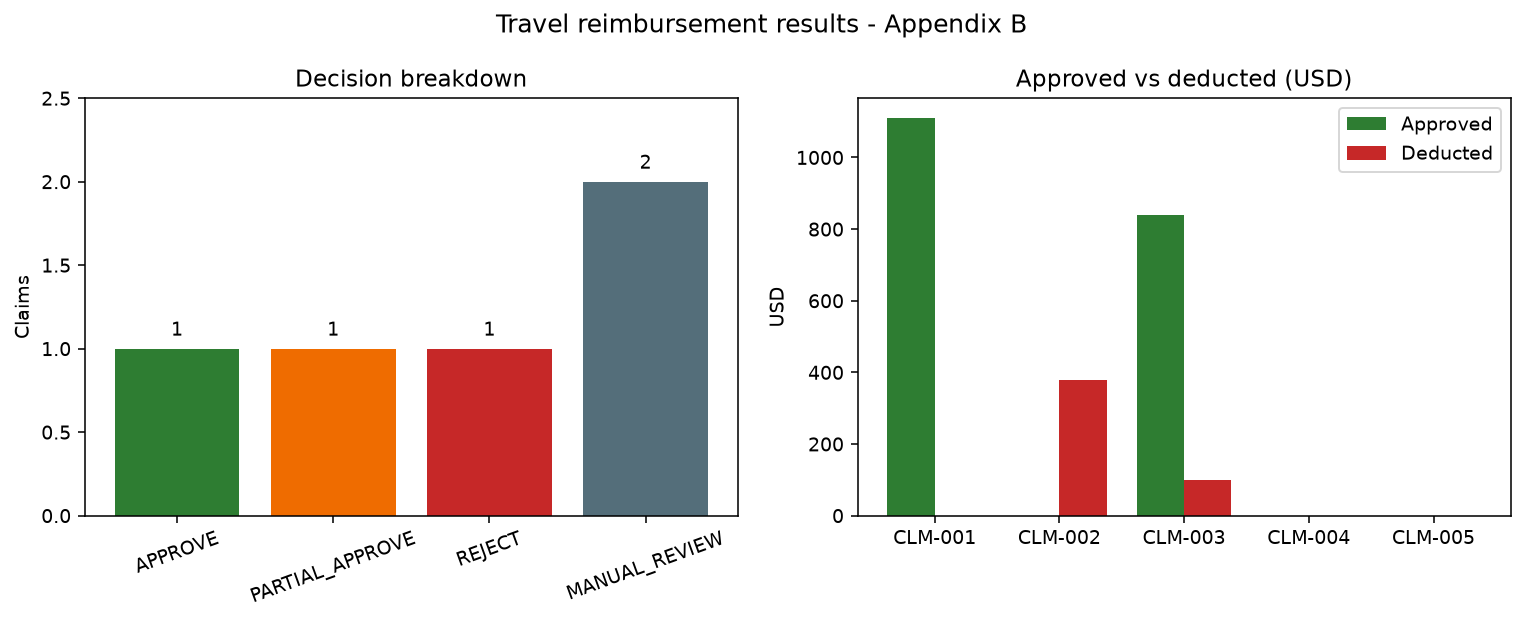

Saved C:\projects\Assignment\UI SS_1.png


In [7]:
labels = list(DECISIONS)
counts = [sum(1 for item in results if item["decision"] == label) for label in labels]
claim_ids = [item["claim_id"] for item in results]
approved = [item["approved_amount"] for item in results]
deducted = [item["deducted_amount"] for item in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = ["#2e7d32", "#ef6c00", "#c62828", "#546e7a"]
axes[0].bar(labels, counts, color=colors)
axes[0].set_title("Decision breakdown")
axes[0].set_ylabel("Claims")
axes[0].set_ylim(0, max(counts + [1]) + 0.5)
axes[0].tick_params(axis="x", rotation=20)
for index, count in enumerate(counts):
    axes[0].text(index, count + 0.05, str(count), ha="center", va="bottom")

positions = list(range(len(claim_ids)))
width = 0.38
axes[1].bar([i - width / 2 for i in positions], approved, width=width, label="Approved", color="#2e7d32")
axes[1].bar([i + width / 2 for i in positions], deducted, width=width, label="Deducted", color="#c62828")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(claim_ids)
axes[1].set_title("Approved vs deducted (USD)")
axes[1].set_ylabel("USD")
axes[1].legend()

fig.suptitle("Travel reimbursement results - Appendix B", fontsize=13)
fig.tight_layout()
chart_path = Path("UI SS_1.png")
fig.savefig(chart_path, dpi=140, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(chart_path)))
print("Saved " + str(chart_path.resolve()))


## Design Notes & Reasoning

### Assumptions

- Currency is USD, as stated for Appendix B.
- The expense date for POL-TIME-01 is the trip end date. The sample lines do not have their own dates.
- Night and day counts used for caps come from the line description. On a same-day trip, a meal line with no day count is one day.
- A duplicate is another of the five sample claims with the same employee and overlapping trip dates. This sample set has none.
- Conference registration has no numeric cap in Appendix A, so a receipt-backed registration fee is reimbursed in full.
- `tools_used` is the list of tools that actually ran, in first-seen order.
- For Manual Review, `approved_amount` and `deducted_amount` are both 0. The claim is held. POL-AIR-01 says not to auto-deduct a business or first-class fare, and POL-RCT-02 says not to silently reject a missing receipt.

### Why some cases go to Manual Review

Manual Review is used when a forced payment would invent a fact the policy does not give the agent:

- Business or first-class airfare can have a pre-approval the packet does not show (POL-AIR-01).
- A missing required receipt has to be requested, not treated as a rejection (POL-RCT-02). A meal that is also over the daily cap stays in Manual Review until that receipt is present. The cap is not applied as an automatic partial approval while the receipt is missing.
- A reimbursable total above USD 2,000 needs a director (POL-APR-03), even when the lines look compliant.
- A late claim, more than 30 days after the expense date, is the same kind of hold (POL-TIME-01). So is an ambiguous line or a duplicate.

Approve is only for a fully compliant claim inside POL-APR-01 or POL-APR-02. Partial Approve is the per-diem case: pay up to the cap and deduct the excess. Reject is reserved for a claim whose lines are ineligible under POL-CAT-02 and leave nothing to reimburse.

A manager-tier total, over USD 500 through USD 2,000, is still an approval when the rest of the policy is satisfied. It is not sent to Manual Review only because it is above USD 500.

### Trade-offs

- The notebook uses a free-tier Gemini model with a manual tool loop. That shows which tool was chosen, and it keeps the demo in one file.
- Caps and receipt rules live in tools. The model writes the decision and the explanation. A local check sends the draft back when the amounts or the route disagree with those tools. The check does not paste over the model's JSON.
- Temperature is 0 so a second run should take the same route. The wording of the explanation can still vary slightly.
- Duplicate detection looks only at the five given claims. There is no historical claim store.

### What I would improve next

- Keep the tool trace as an audit record outside the notebook output.
- Read merchant, date, and amount from receipt images instead of a yes/no flag.
- Use city-level per-diems and a real duplicate index.
- Send Manual Review into a queue with a reason code a person can accept or return.


In [8]:
print(json.dumps(results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-AIR-01",
      "POL-RCT-01",
      "POL-APR-02",
      "POL-TIME-01"
    ],
    "confidence": 0.95,
    "explanation": "Claim CLM-001 is fully compliant with travel policies. All line items (airfare, lodging, meals, and conference fees) are eligible under POL-CAT-01 and within their respective limits (meals are within the USD 75/day cap under POL-PD-01, and lodging is within the USD 200/night cap under POL-PD-02). Receipts are attached for all items as required by POL-RCT-01. The claim was submitted within the 30-day window per POL-TIME-01, and there are no duplicates. The total reimbursable amount of USD 1,110.00 falls under the manager approval tier (POL-APR-02), and the claim is fully approved.",
    "tools_used": [
      "check_receipt_completeness",
  